# Thai Vowel Classification — CNN+LSTM + Mel Spectrogram

**Model:** CNN → Reshape → Bidirectional LSTM → Dense

**Input:** Log-Mel Spectrogram

**Evaluation:** 10% held-out test set → Stratified 5-fold CV on remaining 90%

**Preprocessing:** smart_crop() (peak-energy 500 ms window)

## Section 1 — Setup

In [1]:
import os
import random
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import matplotlib.font_manager as fm
import urllib.request
from pydub import AudioSegment
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

# from google.colab import drive
# drive.mount('/content/drive')

2026-06-28 12:45:50.658360: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-28 12:45:50.698773: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-28 12:45:51.812304: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# ── Constants ───────────────────────────────────────────────
SR          = 16000
HOP_LENGTH  = 512
N_FFT       = 2048
N_CLASSES   = 18
EPOCHS      = 100
BATCH_SIZE  = 32
RANDOM_SEED = 42
N_FOLDS     = 5

VOWEL_LABELS = [
    'อา','อี','อือ','อู','เอ','แอ','โอ','ออ','เออ',
    'อะ','อิ','อึ','อุ','เอะ','แอะ','โอะ','เอาะ','เออะ'
]

# ── Fix Random Seed ─────────────────────────────────────────
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f'Random seed fixed: {RANDOM_SEED}')

Random seed fixed: 42


## Section 2 — Load Dataset

In [3]:
# import os

# base_path = r"dataset"

# for label in os.listdir(base_path):
#     folder = os.path.join(base_path, label)
#     print(f"Folder: {folder}")
#     print("Is directory:", os.path.isdir(folder))

#     if os.path.isdir(folder):
#         files = os.listdir(folder)
#         print("Files:", files)
#         print()

In [4]:
base_path = r'dataset'

data = []
for label in os.listdir(base_path):
    folder = os.path.join(base_path, label)
    if os.path.isdir(folder):
        for file in os.listdir(folder):
            if file.endswith('.wav'):
                data.append([os.path.join(folder, file), label])

df = pd.DataFrame(data, columns=['file_path', 'label'])
print(f'Total samples : {len(df)}')
print(df['label'].value_counts())

Total samples : 1800
label
01    100
02    100
03    100
04    100
05    100
06    100
07    100
08    100
09    100
s1    100
s2    100
s3    100
s4    100
s5    100
s6    100
s7    100
s8    100
s9    100
Name: count, dtype: int64


## Section 3 — Preprocessing Functions

In [5]:
def detect_leading_silence(sound, silence_threshold=-30.0, chunk_size=10):
    """Trim silence from both ends."""
    trim_ms = 0
    while trim_ms < len(sound) and sound[trim_ms:trim_ms+chunk_size].dBFS < silence_threshold:
        trim_ms += chunk_size
    return trim_ms


def smart_crop(file_path, output_dir, window_ms=500, silence_threshold=-30.0):
    """
    Peak-energy crop: trim silence → find frame with max RMS energy
    → crop window_ms centred on that peak.
    Replaces the old fixed 25-50-25 crop.
    """
    os.makedirs(output_dir, exist_ok=True)
    sound = AudioSegment.from_file(file_path)

    start = detect_leading_silence(sound, silence_threshold)
    end   = detect_leading_silence(sound.reverse(), silence_threshold)
    trimmed = sound[start : len(sound) - end]

    if len(trimmed) == 0:
        trimmed = sound

    chunk_ms  = 10
    energies  = [trimmed[i:i+chunk_ms].rms for i in range(0, len(trimmed), chunk_ms)]
    peak_idx  = int(np.argmax(energies))
    peak_ms   = peak_idx * chunk_ms

    half       = window_ms // 2
    crop_start = max(0, peak_ms - half)
    crop_end   = min(len(trimmed), crop_start + window_ms)
    final      = trimmed[crop_start:crop_end]

    out_path = os.path.join(output_dir, f'sc_{os.path.basename(file_path)}')
    final.export(out_path, format='wav')
    return out_path

## Section 4 — Feature Extraction (Log-Mel Spectrogram)

In [6]:
def extract_mel(file_path, max_len=18):
    """
    Extract log-Mel spectrogram → shape (n_mels, max_len).
    Per-sample normalization for stable training.
    """
    wave, _ = librosa.load(file_path, mono=True, sr=SR)

    mel    = librosa.feature.melspectrogram(y=wave, sr=SR,
                                             n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] < max_len:
        mel_db = np.pad(mel_db, ((0,0),(0, max_len - mel_db.shape[1])), mode='constant')
    else:
        mel_db = mel_db[:, :max_len]

    # Per-sample normalization → stable gradient across all folds
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)

    return mel_db  # (n_mels, max_len)

## Section 5 — Dataset Analysis (duration percentiles)

Run once to justify MAX_LEN choice.

In [7]:
durations = []
for fp in tqdm(df['file_path'], desc='Measuring durations'):
    y, _ = librosa.load(fp, sr=SR)
    durations.append(len(y) / SR)

durations = np.array(durations)
print('Duration stats (seconds):')
for p in [25, 50, 75, 90, 95]:
    frames = int(np.percentile(durations, p) * SR / HOP_LENGTH)
    print(f'  p{p}: {np.percentile(durations, p):.3f}s → {frames} frames')

Measuring durations:   0%|                                                                     | 0/1800 [00:00<?, ?it/s]/home/wara/anaconda3/envs/thesis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Measuring durations: 100%|██████████████████████████████████████████████████████████| 1800/1800 [00:18<00:00, 97.15it/s]

Duration stats (seconds):
  p25: 0.123s → 3 frames
  p50: 0.226s → 7 frames
  p75: 0.375s → 11 frames
  p90: 0.491s → 15 frames
  p95: 0.576s → 18 frames


## Section 6 — Build Full Dataset

In [8]:
PROC_DIR  = 'train/proc_smartcrop'
MAX_LEN   = 18  # p95 from duration analysis

processed_paths = [
    smart_crop(fp, PROC_DIR)
    for fp in tqdm(df['file_path'], desc='smart_crop')
]

X = np.array([
    extract_mel(p, max_len=MAX_LEN)
    for p in tqdm(processed_paths, desc='Mel extraction')
])  # (N, N_MELS, MAX_LEN)

le    = LabelEncoder()
y_int = le.fit_transform(df['label'])

print(f'X shape : {X.shape}')
print(f'Classes : {le.classes_}')

Mel extraction:  20%|████████████▌                                                   | 355/1800 [00:07<00:18, 76.52it/s]/home/wara/anaconda3/envs/thesis/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1936
  warnings.warn(
Mel extraction:  50%|███████████████████████████████▊                                | 894/1800 [00:14<00:12, 72.23it/s]/home/wara/anaconda3/envs/thesis/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1200
  warnings.warn(
/home/wara/anaconda3/envs/thesis/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1280
  warnings.warn(
Mel extraction:  50%|████████████████████████████████                                | 903/1800 [00:14<00:11, 75.50it/s]/home/wara/anaconda3/envs/thesis/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n

X shape : (1800, 128, 18)
Classes : ['01' '02' '03' '04' '05' '06' '07' '08' '09' 's1' 's2' 's3' 's4' 's5'
 's6' 's7' 's8' 's9']


## Section 7 — Hold-Out Test Split (25%)

In [9]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_int,
    test_size=0.10,
    random_state=RANDOM_SEED,
    stratify=y_int
)

print(f'Train+Val : {X_trainval.shape[0]} samples')
print(f'Test      : {X_test.shape[0]} samples')

Train+Val : 1620 samples
Test      : 180 samples


## Section 8 — Model Architecture (CNN)

In [10]:
def build_model(input_shape):
   
    inp = layers.Input(shape=input_shape)


    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inp)

    x = layers.MaxPooling2D((2,1))(x)


    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)



    x = layers.Permute((2, 1, 3))(x)
    shape = x.shape
    x = layers.Reshape((shape[1], shape[2] * shape[3]))(x)


    x = layers.LSTM(512, activation='tanh', return_sequences=True, dropout=0.35)(x)
    x = layers.LSTM(512, activation='tanh', return_sequences=False, dropout=0.35)(x)
    x = layers.Dropout(0.35)(x)


    out = layers.Dense(N_CLASSES, activation='softmax')(x)

    model = models.Model(inp, out)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

dummy = build_model((X_trainval.shape[1], X_trainval.shape[2], 1))
dummy.summary()

I0000 00:00:1782625623.768972   30996 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 18, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 18, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 18, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 18, 4096)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 18, 512)        │     9,439,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 512)            │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 18)             │         9,234 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,566,482 (44.12 MB)

 Trainable params: 11,566,482 (44.12 MB)

 Non-trainable params: 0 (0.00 B)

## Section 9 — Stratified 5-Fold Cross-Validation

In [11]:
skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
fold_results = []

X_tv = X_trainval[..., np.newaxis]  # add channel dim

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    print(f'\n── Fold {fold}/{N_FOLDS} ──')

    random.seed(RANDOM_SEED * fold)
    np.random.seed(RANDOM_SEED * fold)
    tf.random.set_seed(RANDOM_SEED * fold)

    X_tr,  X_val  = X_tv[tr_idx],      X_tv[val_idx]
    y_tr,  y_val  = y_trainval[tr_idx], y_trainval[val_idx]

    y_tr_cat  = to_categorical(y_tr,  N_CLASSES)
    y_val_cat = to_categorical(y_val, N_CLASSES)

    model = build_model(X_tr.shape[1:])
    es    = EarlyStopping(monitor='val_loss', patience=15,
                          restore_best_weights=True, verbose=0)

    model.fit(
        X_tr, y_tr_cat,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val_cat),
        callbacks=[es], verbose=0
    )


    val_loss, val_acc_eval = model.evaluate(X_val, y_val_cat, verbose=0)
    train_loss, train_acc_eval = model.evaluate(X_tr, y_tr_cat, verbose=0)

    y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    f1     = f1_score(y_val, y_pred, average='macro')
    acc    = np.mean(y_pred == y_val)

    fold_results.append({
        'fold': fold,
        'val_acc': acc,
        'val_f1_macro': f1,
        'val_loss': val_loss,
        'train_loss': train_loss,
    })
    print(f'  Val Acc: {acc*100:.2f}%   Macro F1: {f1:.4f}   Val Loss: {val_loss:.4f}   Train Loss: {train_loss:.4f}')

df_folds = pd.DataFrame(fold_results)
print('\n' + '='*55)
print('  CV Summary')
print('='*55)
print(f"  Val Acc    : {df_folds['val_acc'].mean()*100:.2f}% ± {df_folds['val_acc'].std()*100:.2f}%")
print(f"  Macro F1   : {df_folds['val_f1_macro'].mean():.4f} ± {df_folds['val_f1_macro'].std():.4f}")
print(f"  Val Loss   : {df_folds['val_loss'].mean():.4f} ± {df_folds['val_loss'].std():.4f}")
print(f"  Train Loss : {df_folds['train_loss'].mean():.4f} ± {df_folds['train_loss'].std():.4f}")
print('='*55)


── Fold 1/5 ──


2026-06-28 12:47:06.100089: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300


  Val Acc: 95.68%   Macro F1: 0.9564   Val Loss: 0.2083   Train Loss: 0.0044

── Fold 2/5 ──
  Val Acc: 96.60%   Macro F1: 0.9659   Val Loss: 0.1305   Train Loss: 0.0059

── Fold 3/5 ──
  Val Acc: 97.84%   Macro F1: 0.9785   Val Loss: 0.1300   Train Loss: 0.0167

── Fold 4/5 ──
  Val Acc: 93.83%   Macro F1: 0.9385   Val Loss: 0.2053   Train Loss: 0.0214

── Fold 5/5 ──
  Val Acc: 92.90%   Macro F1: 0.9284   Val Loss: 0.2775   Train Loss: 0.0222

  CV Summary
  Val Acc    : 95.37% ± 2.01%
  Macro F1   : 0.9535 ± 0.0203
  Val Loss   : 0.1903 ± 0.0620
  Train Loss : 0.0141 ± 0.0085


## Section 10 — Train Final Model

In [12]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

X_tv_final = X_trainval[..., np.newaxis]
y_tv_cat   = to_categorical(y_trainval, N_CLASSES)

X_tf, X_vf, y_tf, y_vf = train_test_split(
    X_tv_final, y_tv_cat, test_size=0.1,
    random_state=RANDOM_SEED, stratify=y_trainval
)

final_model = build_model(X_tf.shape[1:])
es_final    = EarlyStopping(monitor='val_loss', patience=15,
                             restore_best_weights=True, verbose=1)

history = final_model.fit(
    X_tf, y_tf,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_vf, y_vf),
    callbacks=[es_final], verbose=1
)
print('Final model trained.')

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.2346 - loss: 2.2311 - val_accuracy: 0.3333 - val_loss: 2.1337
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4678 - loss: 1.4320 - val_accuracy: 0.5494 - val_loss: 1.2901
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6303 - loss: 1.0492 - val_accuracy: 0.6975 - val_loss: 1.1021
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7572 - loss: 0.7821 - val_accuracy: 0.6481 - val_loss: 0.9153
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7812 - loss: 0.6628 - val_accuracy: 0.8086 - val_loss: 0.6990
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8107 - loss: 0.6149 - val_accuracy: 0.8333 - val_loss: 0.5966
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8409 - loss: 0.5039 - val_accuracy: 0.8827 - val_loss: 0.4120
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8690 - loss: 0.4509 - val_accuracy: 0.

## Section 11 — Evaluate on Held-Out Test Set

In [13]:
X_te        = X_test[..., np.newaxis]
y_pred_test = np.argmax(final_model.predict(X_te, verbose=0), axis=1)

test_acc = np.mean(y_pred_test == y_test)
test_f1  = f1_score(y_test, y_pred_test, average='macro')

print('='*45)
print('  FINAL TEST RESULTS (CNN+LSTM + Mel Spectrogram)')
print('='*45)
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Macro F1      : {test_f1:.4f}')
print('='*45)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_test, target_names=VOWEL_LABELS))

  FINAL TEST RESULTS (CNN+LSTM + Mel Spectrogram)
  Test Accuracy : 93.33%
  Macro F1      : 0.9331

Classification Report:
              precision    recall  f1-score   support

          อา       1.00      1.00      1.00        10
          อี       1.00      0.90      0.95        10
         อือ       1.00      0.80      0.89        10
          อู       0.82      0.90      0.86        10
          เอ       1.00      0.90      0.95        10
          แอ       0.91      1.00      0.95        10
          โอ       0.82      0.90      0.86        10
          ออ       1.00      1.00      1.00        10
         เออ       1.00      1.00      1.00        10
          อะ       1.00      1.00      1.00        10
          อิ       0.89      0.80      0.84        10
          อึ       0.91      1.00      0.95        10
          อุ       0.82      0.90      0.86        10
         เอะ       0.90      0.90      0.90        10
         แอะ       1.00      1.00      1.00        10
         โอ

## Section 12 — Confusion Matrix

In [14]:
urllib.request.urlretrieve(
    'https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf',
    'Sarabun-Regular.ttf'
)
fm.fontManager.addfont('Sarabun-Regular.ttf')
plt.rcParams['font.family'] = 'Sarabun'

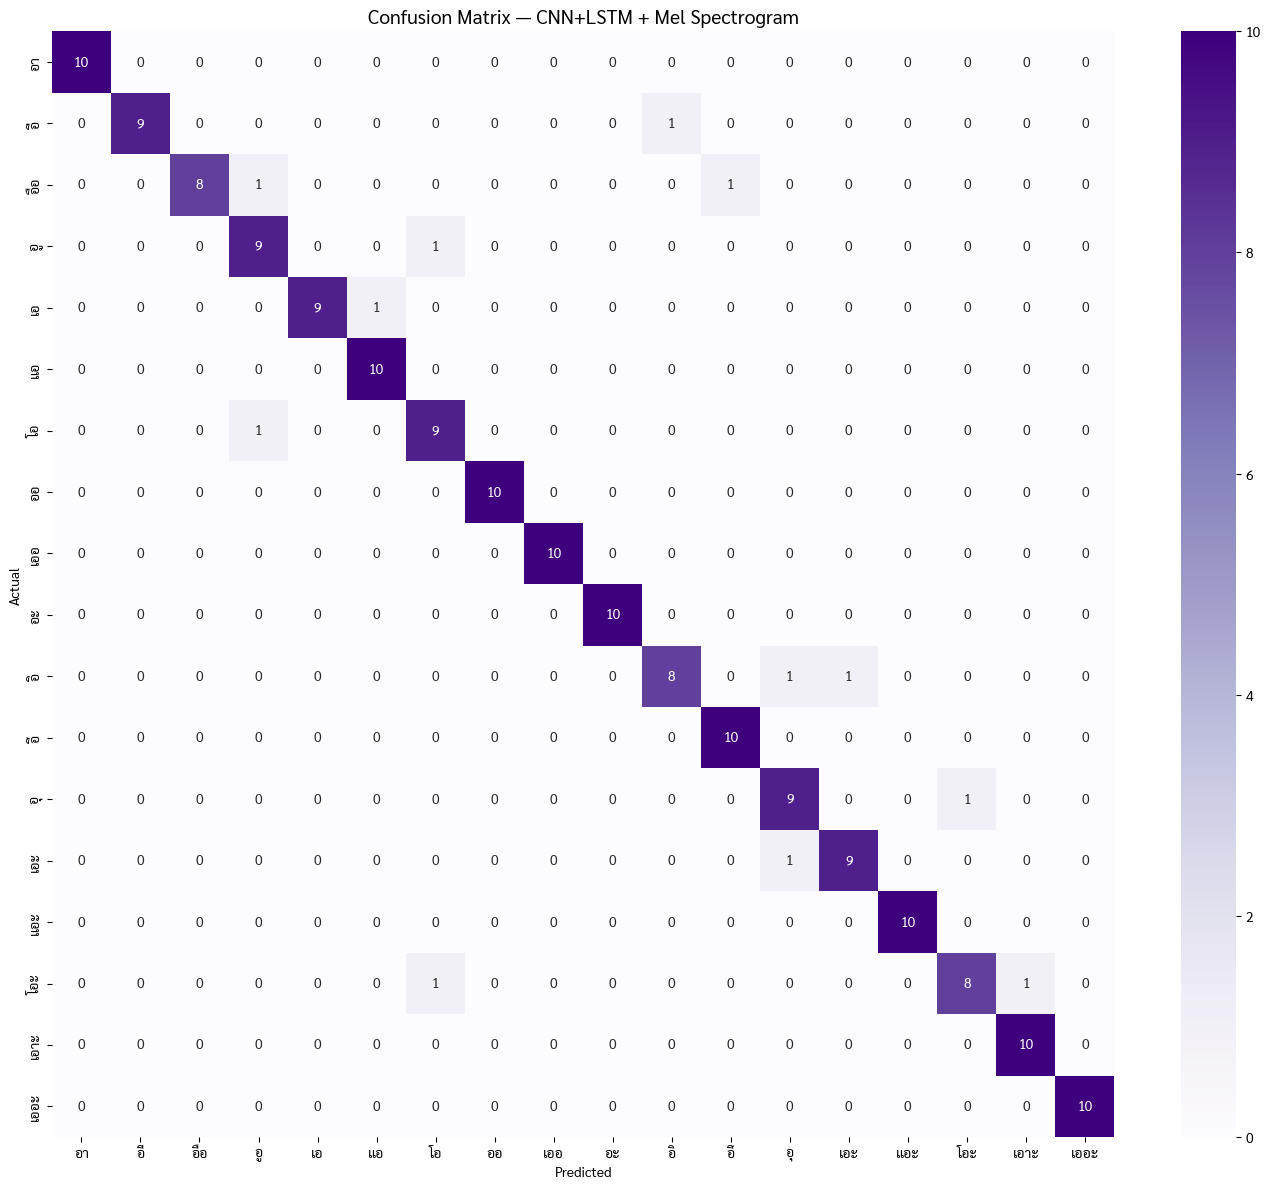

In [15]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=VOWEL_LABELS, yticklabels=VOWEL_LABELS)
plt.title('Confusion Matrix — CNN+LSTM + Mel Spectrogram', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Section 13 — Training Curve

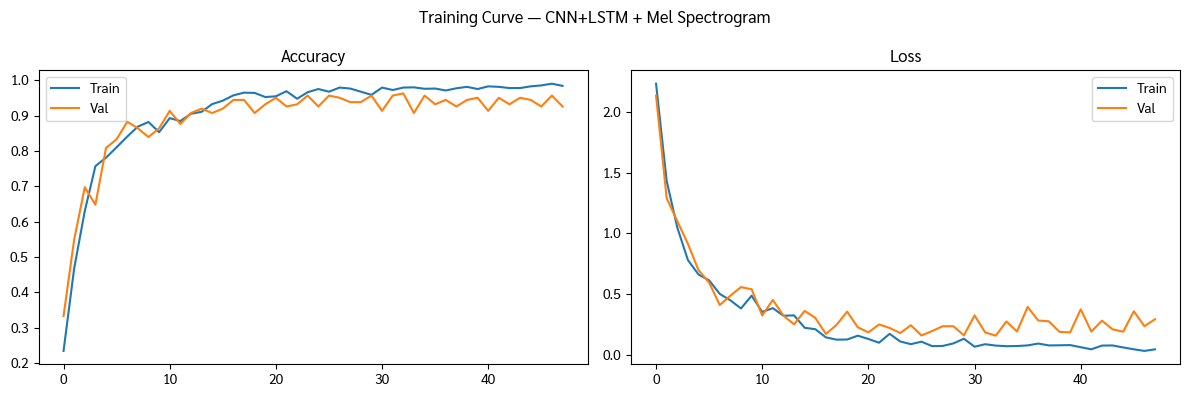

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].legend()

plt.suptitle('Training Curve — CNN+LSTM + Mel Spectrogram')
plt.tight_layout()
plt.show()

## Section 14 — Save Model & Results

In [17]:
print('\n── For comparison table ──')
print(f"CNN+LSTM + Mel Spectrogram | CV F1: {df_folds['val_f1_macro'].mean():.4f}±{df_folds['val_f1_macro'].std():.4f} | Test F1: {test_f1:.4f} | Test Acc: {test_acc*100:.2f}%")


── For comparison table ──
CNN+LSTM + Mel Spectrogram | CV F1: 0.9535±0.0203 | Test F1: 0.9331 | Test Acc: 93.33%
